In [35]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit Learn
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, make_scorer, silhouette_score, classification_report
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# MiniLearn — your from-scratch library
# from minilearn.classifiers import LogisticRegression, KNN, GaussianNaiveBayes, DecisionTreeClassifier
# from minilearn.preprocessing import StandardScaler, train_test_split
# from minilearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
# load processed data
metadata = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_metadata.csv")
features = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_features.csv")

# load dataframes
df = metadata.merge(features, on="filename", how="inner")
features = features.drop(columns=["filename"])


PC1 top features:
rms_std         0.086801
mel_103_mean    0.084225
rms_mean        0.083967
mel_120_mean    0.083700
mel_104_mean    0.083394
mel_121_mean    0.082888
mel_119_mean    0.082837
mel_102_mean    0.081520
mel_115_mean    0.081417
mel_122_mean    0.081335
Name: PC1, dtype: float64

PC2 top features:
chroma_4_mean     0.175738
chroma_3_mean     0.175419
chroma_8_mean     0.172581
chroma_2_mean     0.170026
chroma_9_mean     0.168376
mfcc_6_mean       0.166062
mfcc_7_mean       0.165432
chroma_10_mean    0.160860
mfcc_10_mean      0.159084
chroma_11_mean    0.155132
Name: PC2, dtype: float64

PC3 top features:
mel_111_std     0.125214
mel_110_std     0.120089
mel_109_std     0.120014
mel_117_std     0.118392
mel_112_std     0.117347
mel_110_mean    0.117066
mel_116_std     0.116211
mel_111_mean    0.115288
mel_118_std     0.113012
mel_113_std     0.111997
Name: PC3, dtype: float64

PC4 top features:
mel_6_mean       0.185909
mel_6_std        0.184458
mel_5_mean       0.17588

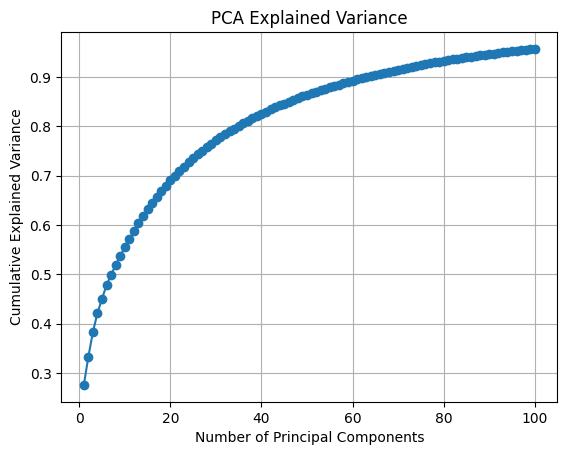

In [14]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.mean(axis=0)[:5]
X_train_scaled.std(axis=0)[:5]

pca = PCA(n_components=100).fit(X_train_scaled)

components_df = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)

components_df.round(4)

for pc in components_df.index:
    print(f"\n{pc} top features:")
    print(
        components_df.loc[pc]
        .abs()
        .sort_values(ascending=False)
        .head(10)
    )

cum_var = np.cumsum(pca.explained_variance_ratio_)

for i, v in enumerate(cum_var, start=1):
    print(f"{i} components explain {v:.2%} of variance")

plt.plot(
    range(1, 101),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

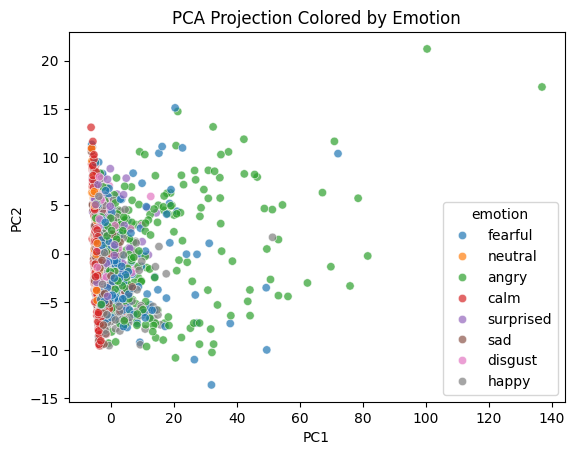

In [17]:
pca_2 = PCA(n_components=2)
X_train_pca_2 = pca_2.fit_transform(X_train_scaled)

pca_plot_df = pd.DataFrame({
    "PC1": X_train_pca_2[:, 0],
    "PC2": X_train_pca_2[:, 1],
    "emotion": y_train.values
})

sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="emotion",
    alpha=0.7
)

plt.title("PCA Projection Colored by Emotion")
plt.show()

In [18]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.mean(axis=0)[:5]
X_train_scaled.std(axis=0)[:5]

pca = PCA(n_components=.9).fit(X_train_scaled)

components_df = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)

components_df.round(4)

for pc in components_df.index:
    print(f"\n{pc} top features:")
    print(
        components_df.loc[pc]
        .abs()
        .sort_values(ascending=False)
        .head(10)
    )

cum_var = np.cumsum(pca.explained_variance_ratio_)

for i, v in enumerate(cum_var, start=1):
    print(f"{i} components explain {v:.2%} of variance")


PC1 top features:
rms_std         0.086801
mel_103_mean    0.084225
rms_mean        0.083967
mel_120_mean    0.083700
mel_104_mean    0.083394
mel_121_mean    0.082888
mel_119_mean    0.082837
mel_102_mean    0.081520
mel_115_mean    0.081417
mel_122_mean    0.081335
Name: PC1, dtype: float64

PC2 top features:
chroma_4_mean     0.175738
chroma_3_mean     0.175419
chroma_8_mean     0.172581
chroma_2_mean     0.170026
chroma_9_mean     0.168376
mfcc_6_mean       0.166062
mfcc_7_mean       0.165432
chroma_10_mean    0.160860
mfcc_10_mean      0.159084
chroma_11_mean    0.155132
Name: PC2, dtype: float64

PC3 top features:
mel_111_std     0.125214
mel_110_std     0.120089
mel_109_std     0.120014
mel_117_std     0.118392
mel_112_std     0.117347
mel_110_mean    0.117066
mel_116_std     0.116211
mel_111_mean    0.115288
mel_118_std     0.113012
mel_113_std     0.111997
Name: PC3, dtype: float64

PC4 top features:
mel_6_mean       0.185909
mel_6_std        0.184458
mel_5_mean       0.17588

In [21]:
for variance in [0.80, 0.90, 0.95]:
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=variance)),
        ("model", SVC(kernel="rbf"))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print(f"\nPCA variance: {variance}")
    print("Components:", pipeline.named_steps["pca"].n_components_)
    print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
    print("Accuracy:", accuracy_score(y_test, y_pred))

    pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf"))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("No PCA")
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Accuracy:", accuracy_score(y_test, y_pred))


PCA variance: 0.8
Components: 35
Macro F1: 0.3687281562901384
Accuracy: 0.41140529531568226

PCA variance: 0.9
Components: 63
Macro F1: 0.44607288994229316
Accuracy: 0.48268839103869654

PCA variance: 0.95
Components: 93
Macro F1: 0.5212075107637585
Accuracy: 0.5356415478615071
No PCA
Macro F1: 0.5668103811190435
Accuracy: 0.5784114052953157


PCA performs pretty poorly

In [ ]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([("scaler", StandardScaler()), ("pca", PCA()), ("model", SVC(kernel="rbf"))])

param_dist = {"pca__n_components": [0.80, 0.85, 0.90, 0.95, 0.99, 20, 30, 40, 50, 60, 70, 80], "model__C": loguniform(1e-2, 1e2), "model__gamma": loguniform(1e-4, 1e0),}

search = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=60, scoring="f1_macro", cv=5, random_state=42, n_jobs=-1)

search.fit(X_train, y_train)

best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

print("Best params:", search.best_params_)
print("CV macro F1:", search.best_score_)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test macro F1:", f1_score(y_test, y_pred, average="macro"))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best params: {'model__C': np.float64(3.14351974471359), 'model__gamma': np.float64(0.0015224209209544581), 'pca__n_components': 0.99}
CV macro F1: 0.6130894688569906
Test accuracy: 0.6211812627291242
Test macro F1: 0.6104844244390795
[[54  0  3  3  8  0  3  4]
 [ 0 57  1  2  5  0 10  0]
 [ 4  4 17  2  2  1  2  7]
 [ 6  5  1 49  6  0  7  1]
 [ 8  8  1  7 44  0  5  2]
 [ 0  3  1  1  0 23  8  2]
 [ 1 13  5  3  7  1 42  3]
 [ 4  4  3  3  4  1  1 19]]
              precision    recall  f1-score   support

       angry       0.70      0.72      0.71        75
        calm       0.61      0.76      0.67        75
     disgust       0.53      0.44      0.48        39
     fearful       0.70      0.65      0.68        75
       happy       0.58      0.59      0.58        75
     neutral       0.88      0.61      0.72        38
         sad       0.54      0.56      0.55        75
   surprised       0.50      0.49      0.49        39

    accuracy                           0.62       491
   macr

With the features reduced, the model performs worse

In [28]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([("scaler", StandardScaler()), ("lda", LinearDiscriminantAnalysis()), ("model", SVC(kernel="rbf"))])

param_dist = {"lda__n_components": [1, 2, 3, 4, 5, 6, 7], "model__C": loguniform(1e-2, 1e2), "model__gamma": loguniform(1e-4, 1e0),}

search = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=40, scoring="f1_macro", cv=5, random_state=42, n_jobs=-1)

search.fit(X_train, y_train)

best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

print("Best params:", search.best_params_)
print("CV macro F1:", search.best_score_)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test macro F1:", f1_score(y_test, y_pred, average="macro"))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best params: {'lda__n_components': 7, 'model__C': np.float64(15.352246941973492), 'model__gamma': np.float64(0.000541675458324746)}
CV macro F1: 0.5788856559610343
Test accuracy: 0.6028513238289206
Test macro F1: 0.6046446184091179
[[32  2  5 10 11  1  6  8]
 [ 0 57  2  1  5  1  9  0]
 [ 2  2 25  0  1  0  5  4]
 [ 4  3  4 49  5  0  6  4]
 [ 3  6  5 10 44  1  4  2]
 [ 0  2  0  0  3 26  6  1]
 [ 1 17  4  5  4  0 43  1]
 [ 4  3  4  2  4  0  2 20]]
              precision    recall  f1-score   support

       angry       0.70      0.43      0.53        75
        calm       0.62      0.76      0.68        75
     disgust       0.51      0.64      0.57        39
     fearful       0.64      0.65      0.64        75
       happy       0.57      0.59      0.58        75
     neutral       0.90      0.68      0.78        38
         sad       0.53      0.57      0.55        75
   surprised       0.50      0.51      0.51        39

    accuracy                           0.60       491
   macro 

In [37]:
X = features.copy()
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([("scaler", StandardScaler()), ("select", SelectKBest(score_func=mutual_info_classif)), ("model", SVC(kernel="rbf"))])

parameter_distributions = {"select__k": [10, 20, 30, 40, 50, 60, 70, 80, "all"], "model__C": loguniform(1e0, 1e2), "model__gamma": loguniform(1e-4, 1e0), "model__kernel": ["rbf"]}

search = RandomizedSearchCV(estimator=pipeline, param_distributions=parameter_distributions, scoring="f1_macro", n_jobs=-1, cv=5, n_iter=50, random_state=42)

search.fit(X_train, y_train)

best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

print("Best params:", search.best_params_)
print("CV macro F1:", search.best_score_)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test macro F1:", f1_score(y_test, y_pred, average="macro"))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

selected_mask = best_model.named_steps["select"].get_support()
selected_features = X.columns[selected_mask]

print("Selected features:")
print(selected_features.tolist())

Best params: {'model__C': np.float64(4.059611610484305), 'model__gamma': np.float64(0.012561043700013555), 'model__kernel': 'rbf', 'select__k': 'all'}
CV macro F1: 0.6379511555765858
Test accuracy: 0.6924643584521385
Test macro F1: 0.6895908501653476
[[66  0  2  2  3  0  1  1]
 [ 2 56  1  5  5  0  6  0]
 [10  2 16  2  0  0  4  5]
 [17  2  1 49  3  0  2  1]
 [16  3  0  6 46  1  2  1]
 [ 1  1  0  3  0 32  1  0]
 [ 2 10  2  4  2  0 52  3]
 [ 8  2  2  1  3  0  0 23]]
              precision    recall  f1-score   support

       angry       0.54      0.88      0.67        75
        calm       0.74      0.75      0.74        75
     disgust       0.67      0.41      0.51        39
     fearful       0.68      0.65      0.67        75
       happy       0.74      0.61      0.67        75
     neutral       0.97      0.84      0.90        38
         sad       0.76      0.69      0.73        75
   surprised       0.68      0.59      0.63        39

    accuracy                           0.69 

I can't find a way to reduce features while retaining model performance, currently.